## Trabajo Práctico Nro. 4 - CLASIFICANDO INFORMALES EN LA EPH: MÉTODOS DE REGULARIZACIÓN & CART
- Grupo 5 del curso "M73 13 Seminarios Optativos - Taller de Programación"
- Integrantes: Santiago Caballero Yver, Oriana Valentina Gegena y Valeria Eliana Gonzalez.

## Retomando lo hecho en el TP1, TP2 y TP3

In [16]:
# Cargamos librerias a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Cargamos bases de datos T424 y T425
T424 = pd.read_excel('C:/Users/gegen/OneDrive/Documentos/2. Economía Aplicada/Programación/usu_individual_T424.xlsx')
T425 = pd.read_excel('C:/Users/gegen/OneDrive/Documentos/2. Economía Aplicada/Programación/usu_individual_T425.xlsx')


In [17]:
# Variables de interés a utilizar en el análisis (TP1, ampliado con las nuevas para TP4)
variables = [
    "CODUSU", "ANO4", "TRIMESTRE", "NRO_HOGAR", "PONDERA",
    "CH03", "CH04", "CH06", "CH07", "CH08", "CH09", "NIVEL_ED",
    "ESTADO", "CAT_OCUP", "EMPLEO", "SECTOR",
    "PP04B_COD", "PP04C", "PP04D_COD", "P21", "P47T",
    "PP07H", "PP3E_TOT", "PP3F_TOT",
    "CH12", "CH13", "CH14", "COMPONENTE",
    "REGION",
]

T424_v = T424[variables].copy()
T425_v = T425[variables].copy()



In [18]:
# Reemplazamos los datos correspondientes a NS/NC a NaN
def reemplazar_nsnc_por_nan(df):
    df_clean = df.copy()
    vars_cat = ["CAT_OCUP", "EMPLEO", "SECTOR", "CH07", "CH08", "CH09"]
    for col in vars_cat:
        df_clean[col] = df_clean[col].replace(9, np.nan)
    df_clean["P47T"] = df_clean["P47T"].replace(-9, np.nan)  # código centinela de Ns/Nc en P47T
    return df_clean

respondieron_2024 = reemplazar_nsnc_por_nan(T424_v)
respondieron_2025 = reemplazar_nsnc_por_nan(T425_v)


In [19]:
# De quienes respondieron, nos quedamos solo con los ocupados
ocupados_2024 = respondieron_2024[respondieron_2024["ESTADO"] == 1].copy()
ocupados_2025 = respondieron_2025[respondieron_2025["ESTADO"] == 1].copy()


In [20]:
# Creación de variables dicotómicas (TP1)
# Género: 1 = Mujer (CH04 == 2), 0 = Varón (CH04 == 1).
def crear_dummies_tp1(df):
    df = df.copy()
    df["Género"] = np.where(df["CH04"] == 2, 1, 0)
    df["Cobertura"] = np.where(df["CH08"].isna(), np.nan, np.where(df["CH08"] != 4, 1, 0))
    return df


ocupados_2024 = crear_dummies_tp1(ocupados_2024)
ocupados_2025 = crear_dummies_tp1(ocupados_2025)



In [21]:
# Variables construidas en el TP2: edad, edad2, educ, nhogar
def calcular_edad(df):
    df = df.copy()
    df["edad"] = pd.to_numeric(df["CH06"], errors="coerce")
    mascara = df["edad"].between(0, 120)
    df.loc[~mascara, "edad"] = np.nan
    df["edad2"] = df["edad"].pow(2)
    return df


def calcular_años_educacion(df):
    nivel = pd.to_numeric(df["CH12"], errors="coerce").fillna(0)
    termino = pd.to_numeric(df["CH13"], errors="coerce").fillna(0)
    ultimo_año = pd.to_numeric(df["CH14"], errors="coerce").fillna(0)
    ultimo_año = np.where(ultimo_año > 10, 0, ultimo_año)

    condiciones = [
        (nivel == 1) | (nivel == 9),
        (nivel == 2) & (termino == 1),
        (nivel == 2) & (termino == 2),
        (nivel == 3) & (termino == 1),
        (nivel == 3) & (termino == 2),
        (nivel == 4) & (termino == 1),
        (nivel == 4) & (termino == 2),
        (nivel == 5) & (termino == 1),
        (nivel == 5) & (termino == 2),
        (nivel.isin([6, 7])) & (termino == 1),
        (nivel.isin([6, 7])) & (termino == 2),
        (nivel == 8) & (termino == 1),
        (nivel == 8) & (termino == 2),
    ]
    resultados = [
        0,
        7, ultimo_año,
        9, ultimo_año,
        12, 7 + ultimo_año,
        12, 9 + ultimo_año,
        17, 12 + ultimo_año,
        22, 17 + ultimo_año,
    ]
    return np.select(condiciones, resultados, default=np.nan)


def calcular_miembros_hogar(df):
    return df.groupby(["CODUSU", "NRO_HOGAR"])["COMPONENTE"].transform("count")


ocupados_2024 = calcular_edad(ocupados_2024)
ocupados_2025 = calcular_edad(ocupados_2025)

ocupados_2024["educ"] = calcular_años_educacion(ocupados_2024)
ocupados_2025["educ"] = calcular_años_educacion(ocupados_2025)

ocupados_2024["nhogar"] = calcular_miembros_hogar(ocupados_2024)
ocupados_2025["nhogar"] = calcular_miembros_hogar(ocupados_2025)


`horastrab` se calcula acá para todos los ocupados (en el TP3 se calculaba exclusivamente para el jefe de hogar).

In [22]:
def calcular_horas_todos(df):
    h_principal = pd.to_numeric(df["PP3E_TOT"], errors="coerce").mask(
        pd.to_numeric(df["PP3E_TOT"], errors="coerce") == 999)
    h_otras = pd.to_numeric(df["PP3F_TOT"], errors="coerce").mask(
        pd.to_numeric(df["PP3F_TOT"], errors="coerce") == 999)
    return h_principal + h_otras.fillna(0)


ocupados_2024["horastrab"] = calcular_horas_todos(ocupados_2024).clip(upper=168)
ocupados_2025["horastrab"] = calcular_horas_todos(ocupados_2025).clip(upper=168)


In [23]:
def crear_variables_nuevas(df):
    df = df.copy()
    # Estado civil (CH07)
    mapa_ch07 = {1: "unido", 2: "casado", 3: "separado", 4: "viudo", 5: "soltero"}
    df["estado_civil"] = df["CH07"].map(mapa_ch07)

    # Jefe de hogar (CH03 == 1)
    df["es_jefe_hogar"] = np.where(df["CH03"] == 1, 1, 0)

    # Nivel educativo INDEC (categórica, complementaria a "educ" continua)
    mapa_nivel = {
        1: "primaria_incompleta", 2: "primaria_completa",
        3: "secundaria_incompleta", 4: "secundaria_completa",
        5: "superior_incompleta", 6: "superior_completa",
        7: "sin_instruccion",
    }
    df["nivel_ed_cat"] = df["NIVEL_ED"].map(mapa_nivel)

    # Grupo ocupacional: 
    cod_ocup = pd.to_numeric(df["PP04D_COD"], errors="coerce")
    cod_ocup_str = cod_ocup.astype("Int64").astype(str).str.zfill(5)
    df["ocupacion_grupo"] = np.where(
        cod_ocup.between(10000, 99999), "grupo_ocup_" + cod_ocup_str.str[0], np.nan
    )



    # Región geográfica
    mapa_region = {
        1: "gba", 40: "cuyo", 41: "noa", 42: "nea", 43: "pampeana", 44: "patagonia",
    }
    df["region_cat"] = df["REGION"].map(mapa_region)

    # Rama de actividad económica agrupada: primer dígito del código de actividad (PP04B_COD)
    cod_rama = pd.to_numeric(df["PP04B_COD"], errors="coerce")
    cod_rama_str = cod_rama.astype("Int64").astype(str).str.zfill(6)
    df["rama_actividad"] = np.where(
        cod_rama.between(100000, 999999), "rama_" + cod_rama_str.str[0], np.nan
    )

    # Alfabetización (CH09: 1 = Sabe leer y escribir, 2 = No sabe)
    df["alfabetizado"] = np.where(df["CH09"] == 1, 1, np.where(df["CH09"] == 2, 0, np.nan))

    return df


ocupados_2024 = crear_variables_nuevas(ocupados_2024)
ocupados_2025 = crear_variables_nuevas(ocupados_2025)


In [24]:
# Construcción del indicador de informalidad
def construir_informalidad(df):
    cond_informal = (
        ((df["CAT_OCUP"] == 2) & (df["SECTOR"] == 2)) |
        (df["CAT_OCUP"] == 4)
    )
    df = df.copy()
    df["informal_se"] = np.where(
        df["CAT_OCUP"].isna() | df["SECTOR"].isna(),
        np.nan,
        np.where(cond_informal, 1, 0),
    )
    return df


ocupados_2024_final = construir_informalidad(ocupados_2024)
ocupados_2025_final = construir_informalidad(ocupados_2025)

# P21_miles se calcula con fines descriptivos
ocupados_2024_final["P21_miles"] = ocupados_2024_final["P21"] / 1000
ocupados_2025_final["P21_miles"] = ocupados_2025_final["P21"] / 1000

print("informal_se 2024:")
print(ocupados_2024_final["informal_se"].value_counts(dropna=False))
print("\ninformal_se 2025:")
print(ocupados_2025_final["informal_se"].value_counts(dropna=False))


informal_se 2024:
informal_se
0.0    16916
1.0     3359
NaN      857
Name: count, dtype: int64

informal_se 2025:
informal_se
0.0    15524
1.0     3424
NaN      750
Name: count, dtype: int64


In [25]:
# ocupados_X_2025_MM (con el lag de informalidad de 2024)
id_vars = ["CODUSU", "NRO_HOGAR", "COMPONENTE"]

# Predictores del modelo:
variables_X = [
    "edad", "edad2", "educ", "horastrab", "nhogar",
    "Género", "Cobertura", "es_jefe_hogar",
    "estado_civil", "nivel_ed_cat", "ocupacion_grupo",
    "region_cat", "rama_actividad", "alfabetizado",
]

ocupados_X_2024 = ocupados_2024_final[id_vars + variables_X].copy()
y_2024 = ocupados_2024_final["informal_se"]

y_2024_con_id = ocupados_2024_final[id_vars + ["informal_se"]].rename(
    columns={"informal_se": "informal_se_2024"})

base_2025_MM = ocupados_2025_final[id_vars + variables_X + ["informal_se"]].merge(
    y_2024_con_id, on=id_vars, how="inner"
)
y_2025_MM = base_2025_MM["informal_se"]
ocupados_X_2025_MM = base_2025_MM.drop(columns=id_vars + ["informal_se"])
# ocupados_X_2025_MM tiene: variables_X + informal_se_2024 (el lag)

print(f"Cantidad de variables conceptuales en variables_X: {len(variables_X)}")
print(f"Cantidad de variables conceptuales incluyendo el lag informal_se_2024: {len(variables_X) + 1}")


Cantidad de variables conceptuales en variables_X: 14
Cantidad de variables conceptuales incluyendo el lag informal_se_2024: 15


In [26]:
# Matriz de diseño: dummies + dropna + constante
def preparar_X(df):
    df = df.copy()
    cols_categoricas = ["estado_civil", "nivel_ed_cat", "ocupacion_grupo",
                         "region_cat", "rama_actividad"]
    df = pd.get_dummies(df, columns=cols_categoricas, drop_first=True)
    df = df.astype(float)
    return df


X_2024 = preparar_X(ocupados_X_2024[variables_X])
X_2025_MM = preparar_X(ocupados_X_2025_MM)

datos_2024 = pd.concat([X_2024, y_2024.rename("y")], axis=1).dropna()
datos_2025_MM = pd.concat([X_2025_MM, y_2025_MM.rename("y")], axis=1).dropna()

print(f"Observaciones 2024 (post dropna): {datos_2024.shape[0]}")
print(f"Observaciones 2025_MM (post dropna): {datos_2025_MM.shape[0]}")
print(f"Cantidad de variables predictoras (post dummies): {X_2024.shape[1]}")
print(f"Cantidad de variables predictoras (conceptuales, sin abrir dummies): {len(variables_X) + 1}")  # +1 por el lag


Observaciones 2024 (post dropna): 20200
Observaciones 2025_MM (post dropna): 6722
Cantidad de variables predictoras (post dummies): 32
Cantidad de variables predictoras (conceptuales, sin abrir dummies): 15


**Diagnóstico previo**: antes de estimar los modelos, se revisa si alguna variable dummy genera cuasi-separación (una categoría que es casi perfectamente informal o casi perfectamente formal), tal como ocurrió con `tam_empresa` en el TP3. Esto ayuda a anticipar problemas de convergencia en la Regresión Logística sin penalizar.

In [27]:
# Diagnóstico de cuasi-separación: para cada dummy, ¿alguna categoría es >97% de una sola clase?
X_diag = datos_2025_MM.drop(columns="y")
y_diag = datos_2025_MM["y"]

print("Variables dummy con posible cuasi-separación (categoría con >97% de una sola clase):\n")
for col in X_diag.columns:
    valores_unicos = X_diag[col].dropna().unique()
    if set(valores_unicos).issubset({0.0, 1.0}):  # es una dummy binaria
        tabla = pd.crosstab(X_diag[col], y_diag, normalize="index")
        if tabla.max(axis=1).max() > 0.97:
            n_obs_cat1 = (X_diag[col] == 1).sum()
            print(f"- {col} (n={n_obs_cat1}):")
            print(tabla.round(4))
            print()


Variables dummy con posible cuasi-separación (categoría con >97% de una sola clase):

- ocupacion_grupo_grupo_ocup_2 (n=282):
y                                0.0     1.0
ocupacion_grupo_grupo_ocup_2                
0.0                           0.8331  0.1669
1.0                           0.9965  0.0035



## A. Modelo de Regresión Logística con Regularización: Ridge y LASSO

### A.1. Visualización: coeficientes de LASSO y Ridge en función de λ

Se grafican en dos paneles distintos los coeficientes de LASSO y Ridge para la grilla de parámetros de penalización λ = 10ⁿ, con n ∈ {-5,-4,-3,...,4,5}. En LogisticRegression de sklearn, el parámetro C es el inverso de la fuerza de penalización (C = 1/λ), por lo que se construye la grilla de C a partir de la de λ. Se utiliza el solver liblinear para LASSO (penalización L1) y lbfgs para Ridge (penalización L2), recomendados por su eficiencia computacional con este tipo de matriz de diseño.


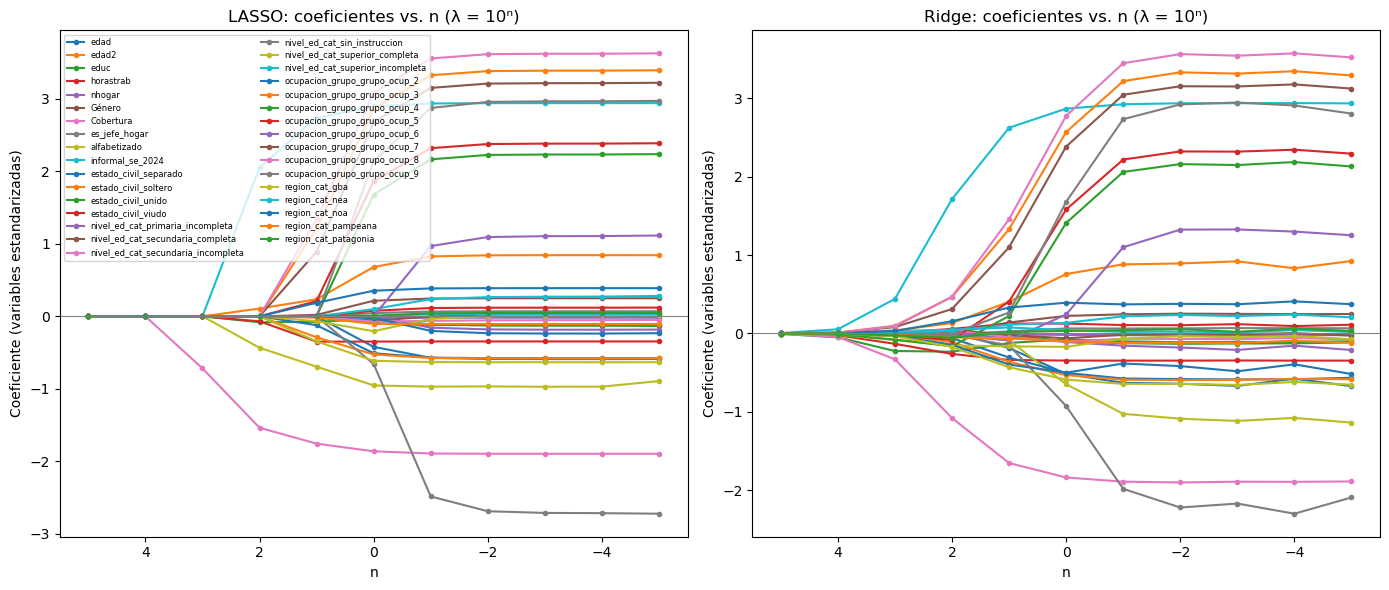

In [28]:
X = datos_2025_MM.drop(columns="y")
y = datos_2025_MM["y"]
nombres_X = X.columns.tolist()

# Estandarizamos las variables continuas (no las dummies) para mejorar la convergencia
# de lbfgs y hacer comparables los coeficientes entre variables de escalas distintas.
vars_continuas = ["edad", "edad2", "educ", "horastrab", "nhogar"]
scaler = StandardScaler()
X_esc = X.copy()
X_esc[vars_continuas] = scaler.fit_transform(X[vars_continuas])

# Grilla de penalización: lambda = 10^n, con C = 1/lambda (parámetro de sklearn)
n_grid = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
lambdas = 10.0 ** n_grid
Cs = 1.0 / lambdas

coefs_lasso = []
coefs_ridge = []

for C in Cs:
    m_l1 = LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=5000)
    m_l1.fit(X_esc, y)
    coefs_lasso.append(m_l1.coef_.ravel())

    m_l2 = LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=5000)
    m_l2.fit(X_esc, y)
    coefs_ridge.append(m_l2.coef_.ravel())

coefs_lasso = np.array(coefs_lasso)  # filas = lambda, columnas = variables
coefs_ridge = np.array(coefs_ridge)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for j, nombre in enumerate(nombres_X):
    axes[0].plot(n_grid, coefs_lasso[:, j], marker="o", markersize=3, label=nombre)
    axes[1].plot(n_grid, coefs_ridge[:, j], marker="o", markersize=3, label=nombre)

axes[0].set_title("LASSO: coeficientes vs. n (λ = 10ⁿ)")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Coeficiente (variables estandarizadas)")
axes[0].axhline(0, color="grey", linewidth=0.8)
axes[0].invert_xaxis()

axes[1].set_title("Ridge: coeficientes vs. n (λ = 10ⁿ)")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Coeficiente (variables estandarizadas)")
axes[1].axhline(0, color="grey", linewidth=0.8)
axes[1].invert_xaxis()

axes[0].legend(fontsize=6, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()


In [29]:
# Identifica las variables con mayor magnitud de coeficiente en el extremo de penalización débil
idx_n_min = np.argmin(n_grid) 
extremos_lasso = pd.Series(coefs_lasso[idx_n_min], index=nombres_X).sort_values()
extremos_ridge = pd.Series(coefs_ridge[idx_n_min], index=nombres_X).sort_values()

print("LASSO — 5 coeficientes más negativos y 5 más positivos (n=-5):")
print(pd.concat([extremos_lasso.head(5), extremos_lasso.tail(5)]))

print("\nRidge — 5 coeficientes más negativos y 5 más positivos (n=-5):")
print(pd.concat([extremos_ridge.head(5), extremos_ridge.tail(5)]))

LASSO — 5 coeficientes más negativos y 5 más positivos (n=-5):
nivel_ed_cat_sin_instruccion   -2.721919
Cobertura                      -1.895378
alfabetizado                   -0.892602
region_cat_gba                 -0.632764
edad                           -0.588731
informal_se_2024                2.940698
ocupacion_grupo_grupo_ocup_9    2.971263
ocupacion_grupo_grupo_ocup_7    3.221168
ocupacion_grupo_grupo_ocup_3    3.393536
ocupacion_grupo_grupo_ocup_8    3.627036
dtype: float64

Ridge — 5 coeficientes más negativos y 5 más positivos (n=-5):
nivel_ed_cat_sin_instruccion   -2.090689
Cobertura                      -1.886524
alfabetizado                   -1.135776
edad                           -0.671688
region_cat_gba                 -0.652791
ocupacion_grupo_grupo_ocup_9    2.803467
informal_se_2024                2.933599
ocupacion_grupo_grupo_ocup_7    3.122377
ocupacion_grupo_grupo_ocup_3    3.289700
ocupacion_grupo_grupo_ocup_8    3.519862
dtype: float64


Observamos que a medida que n aumenta (mayor penalización, λ más grande), los coeficientes de LASSO se contraen hacia cero de forma abrupta, incluso varios llegan a anularse exactament, mientras que los de Ridge se achican de forma suave y continua, sin llegar nunca a cero exacto. Esta es la 
diferencia estructural entre ambas penalizaciones, LASSO realiza selección de variables (coeficientes exactamente nulos), Ridge solo achica su magnitud.

En el extremo de penalización débil (n=-5), siete variables se separan claramente del resto en magnitud, mientras que el resto de los predictores se concentra por debajo de |1|: cuatro categorías de ocupacion_grupo (grupos 3, 7, 8 y 9, todas asociadas a MAYOR informalidad, con coeficientes de +2,8 a +3,6), informal_se_2024 (+2,94, en línea con la magnitud de estas categorías, prácticamente empatado con el grupo ocupacional 9, y superado claramente solo por los grupos 3, 7 y 8), nivel_ed_cat_sin_instruccion (asociada
a MENOR informalidad, con -2,7 en LASSO y -2,1 en Ridge) y Cobertura (también asociada a MENOR informalidad, con -1,9 en ambas penalizaciones). Esto es esperable ya que varios de los nueve grupos ocupacionales son categorías con pocas observaciones, que el logit sin penalizar (y, en menor medida, LASSO y Ridge incluso con penalización débil) ajusta con coeficientes extremos.



### A.2. Penalidad óptima por Cross-Validation y visualización

Usando `StratifiedKFold` con 5 particiones (5-fold), se elige la penalización λ óptima en la grilla mencionada arriba, para LASSO y para Ridge por separado. Se generan box-plots mostrando la distribución del error de clasificación de validación para cada valor de λ, donde cada caja corresponde a un valor de λ y contiene como observaciones el error de clasificación de validación de cada partición.

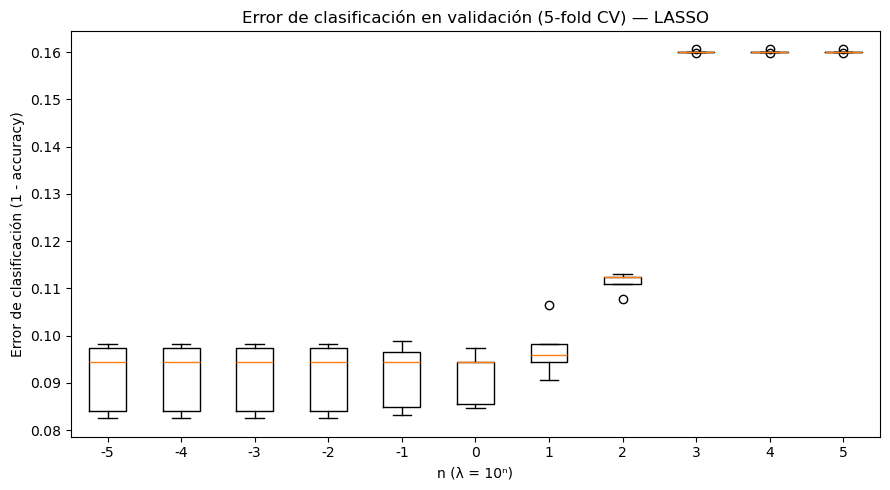

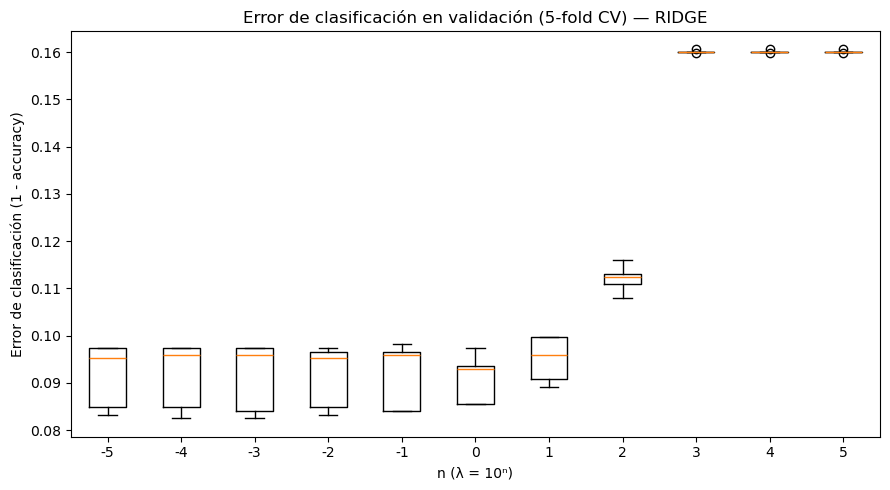

n óptimo LASSO = -5 (λ = 1e-05), error medio de validación = 0.0913
n óptimo Ridge = 0 (λ = 1e+00), error medio de validación = 0.0910


In [30]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = {"lasso": {}, "ridge": {}}
for n, C in zip(n_grid, Cs):
    m_l1 = LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=5000)
    scores_l1 = cross_val_score(m_l1, X_esc, y, cv=skf, scoring="accuracy")
    resultados_cv["lasso"][n] = 1 - scores_l1  # error de clasificación por partición

    m_l2 = LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=5000)
    scores_l2 = cross_val_score(m_l2, X_esc, y, cv=skf, scoring="accuracy")
    resultados_cv["ridge"][n] = 1 - scores_l2

for metodo in ["lasso", "ridge"]:
    fig, ax = plt.subplots(figsize=(9, 5))
    data_box = [resultados_cv[metodo][n] for n in n_grid]
    ax.boxplot(data_box, tick_labels=n_grid)
    ax.set_title(f"Error de clasificación en validación (5-fold CV) — {metodo.upper()}")
    ax.set_xlabel("n (λ = 10ⁿ)")
    ax.set_ylabel("Error de clasificación (1 - accuracy)")
    plt.tight_layout()
    plt.show()

# lambda óptimo: el que minimiza el error medio de validación
media_error_lasso = {n: resultados_cv["lasso"][n].mean() for n in n_grid}
media_error_ridge = {n: resultados_cv["ridge"][n].mean() for n in n_grid}

n_opt_lasso = min(media_error_lasso, key=media_error_lasso.get)
n_opt_ridge = min(media_error_ridge, key=media_error_ridge.get)
lambda_opt_lasso = 10.0 ** n_opt_lasso
lambda_opt_ridge = 10.0 ** n_opt_ridge

print(f"n óptimo LASSO = {n_opt_lasso} (λ = {lambda_opt_lasso:.0e}), error medio de validación = {media_error_lasso[n_opt_lasso]:.4f}")
print(f"n óptimo Ridge = {n_opt_ridge} (λ = {lambda_opt_ridge:.0e}), error medio de validación = {media_error_ridge[n_opt_ridge]:.4f}")


Para observar la proporción de variables ignoradas por LASSO (coeficiente exactamente cero) en función de λ.

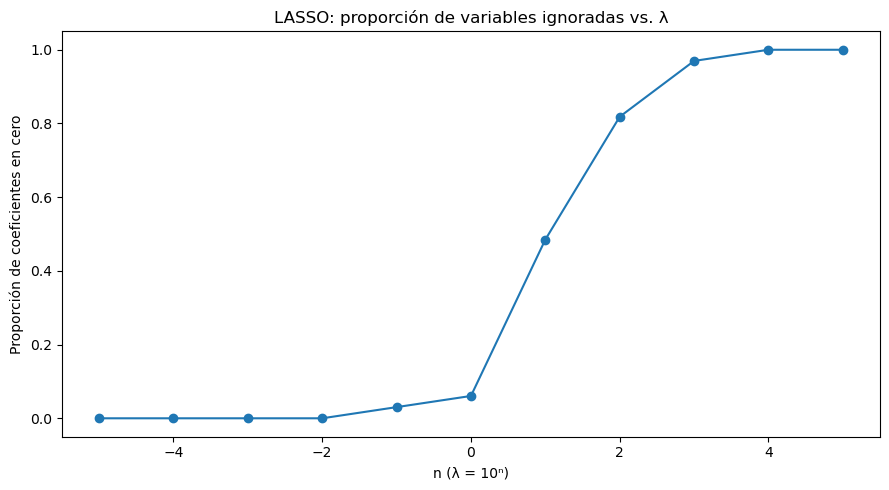

In [31]:
prop_cero = (np.abs(coefs_lasso) < 1e-10).mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_grid, prop_cero, marker="o")
ax.set_xlabel("n (λ = 10ⁿ)")
ax.set_ylabel("Proporción de coeficientes en cero")
ax.set_title("LASSO: proporción de variables ignoradas vs. λ")
plt.tight_layout()
plt.show()


Observamos que la proporción de coeficientes en cero muestra una transición marcada: prácticamente 0% de variables ignoradas entre n=-5 y n=-2, un quiebre a partir de n=0, y saturación casi total desde n=3 (97%-100%). Esto es consistente con que, en el extremo de penalización fuerte, ni siquiera el predictor más robusto (informal_se_2024) sobrevive: el modelo colapsa a predecir la clase mayoritaria.

La penalización óptima elegida por 5-fold CV fue λ = 10⁻⁵ para LASSO (n=-5, error medio de validación = 9,13%) y λ = 10⁰ = 1 para Ridge (n=0, error medio de validación = 9,10%). Los dos errores son prácticamente idénticos, por lo que no hay una ventaja clara de un método sobre el otro en términos de error de clasificación puro.

Que la CV elija la penalización más débil posible para LASSO  tiene sentido con predictores los que tienen coeficientes muy grandes en el logit sin penalizar, varias categorías de `ocupacion_grupo` con cuasi-separación, además de `informal_se_2024`, cualquier penalización más fuerte que la mínima empeora el ajuste dentro de la muestra, porque esas variables extremas aportan mucho poder predictivo. Como consecuencia, con λ=10⁻⁵ LASSO prácticamente no descarta ninguna variable, el algoritmo prioriza retener toda la señal disponible por sobre la interpretabilidad o la selección de variables.


### A.3. Estimación con λ_cv y comparación de coeficientes

Se estima una Regresión Logística sin penalización y se compara con los coeficientes de LASSO y Ridge, cada uno evaluado en su λ óptimo hallado en el punto anterior.

In [32]:
X_sm = sm.add_constant(X_esc)
modelo_sin_penalidad = sm.Logit(y, X_sm).fit(disp=0)

C_opt_lasso = 1.0 / lambda_opt_lasso
C_opt_ridge = 1.0 / lambda_opt_ridge

modelo_l1 = LogisticRegression(penalty="l1", C=C_opt_lasso, solver="liblinear", max_iter=5000)
modelo_l1.fit(X_esc, y)

modelo_l2 = LogisticRegression(penalty="l2", C=C_opt_ridge, solver="lbfgs", max_iter=5000)
modelo_l2.fit(X_esc, y)

tabla_coeficientes = pd.DataFrame({
    "Variable": ["const"] + nombres_X,
    "Sin penalidad": modelo_sin_penalidad.params.values,
    "LASSO (L1)": np.concatenate([[modelo_l1.intercept_[0]], modelo_l1.coef_.ravel()]),
    "Ridge (L2)": np.concatenate([[modelo_l2.intercept_[0]], modelo_l2.coef_.ravel()]),
}).round(4)

# Nota: "Género" en esta tabla toma valor 1 = Mujer, 0 = Varón 
display(tabla_coeficientes)

variables_lasso_cero = tabla_coeficientes.loc[
    (tabla_coeficientes["Variable"] != "const") & (tabla_coeficientes["LASSO (L1)"] == 0), "Variable"
].tolist()
print(f"\nVariables que LASSO llevó a cero (n óptimo = {n_opt_lasso}): {variables_lasso_cero}")


,Variable,Sin penalidad,LASSO (L1),Ridge (L2)
0,const,-3.2771,-3.1565,-2.6085
1,edad,-0.5885,-0.5893,-0.5157
2,edad2,0.8429,0.8436,0.7580
3,educ,-0.1345,-0.1288,-0.0747
4,horastrab,-0.3461,-0.3461,-0.3452
5,nhogar,-0.0188,-0.0191,-0.0184
6,Género,0.2491,0.2489,0.2241
7,Cobertura,-1.8953,-1.8957,-1.8359
8,es_jefe_hogar,0.0697,0.0692,0.0644
9,alfabetizado,-0.8636,-0.9676,-0.6470



Variables que LASSO llevó a cero (n óptimo = -5): []


In [33]:
#Exportamos a excel
tabla_coeficientes.to_excel("tabla_coeficientes_regularizacion.xlsx", index=False)

Interpretamos que con λ óptimo de LASSO en el borde débil de la grilla (n=-5), no se anula ninguna variable y se comporta casi idéntico al logit sin penalizar (informal_se_2024: 2,9407 en ambos). 

En cambip, Ridge (n=0) contrae de forma pareja la mayoría de los coeficientes (<15%), salvo dos casos de contracción fuerte: nivel_ed_cat_sin_instruccion (-2,72→-0,92, -66%) y ocupacion_grupo_grupo_ocup_6 (1,12→0,24, -78%), señal de estimación inestable, candidatas a revisar por cuasi-separación.

`informal_se_2024` sigue siendo el predictor más fuerte y estable (2,94/2,94/2,87 en los tres modelos), confirmando la dependencia de estado de Maurizio & Monsalvo (2021).

Ridge/L2 no elimina variables, y no puede hacerlo por construcción: la penalización L2 agrega $\lambda \sum \beta_j^2$ a la función objetivo, cuya derivada nunca produce un "codo" en cero como sí lo hace la penalización L1 (norma
$\sum|\beta_j|$). Ridge solo *contrae* los coeficientes hacia cero de forma continua y suave —los reduce en magnitud, algunos mucho, como `nivel_ed_cat_sin_instruccion` (-66%) y `ocupacion_grupo_grupo_ocup_6` (-78%)—, pero ninguno llega a ser exactamente cero.

## B. Árboles

### B.1. Árbol de decisión podado (CART) por Cross-Validation

Se calcula la grilla de valores de costo de complejidad (ccp_alpha) mediante cost_complexity_pruning_path, y se elige el valor óptimo por 5-fold Cross-Validation. Se muestra el error de clasificación en función de la grilla de valores que usó ccp_alpha.

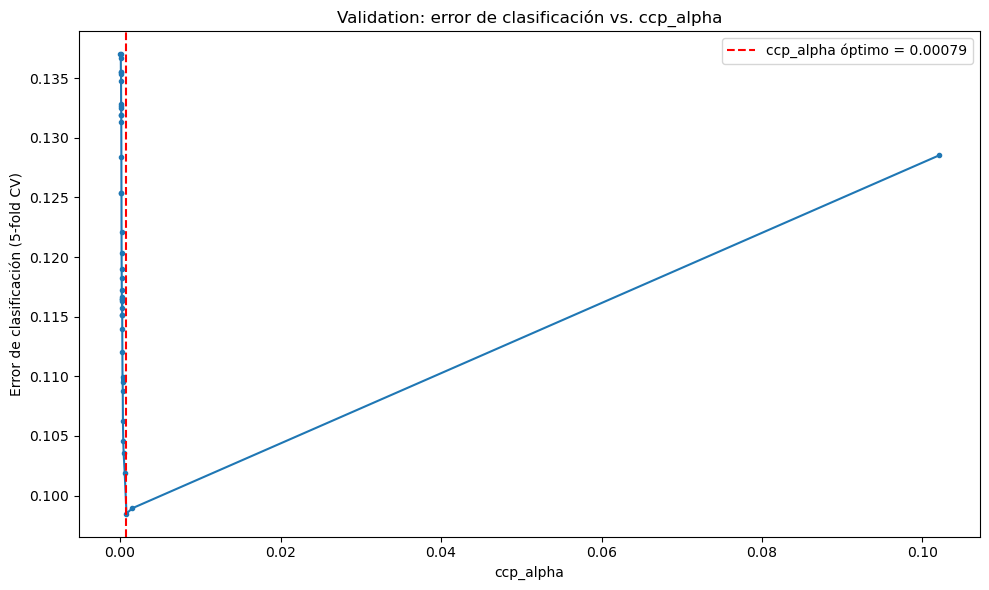

ccp_alpha óptimo = 0.000795, error medio de validación = 0.0985


In [34]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

arbol_completo = DecisionTreeClassifier(random_state=42)
path = arbol_completo.cost_complexity_pruning_path(X, y)
ccp_alphas = np.unique(path.ccp_alphas[path.ccp_alphas >= 0])
if len(ccp_alphas) > 40:
    idx = np.linspace(0, len(ccp_alphas) - 1, 40).astype(int)
    ccp_alphas = ccp_alphas[idx]

errores_cv = []
for alpha in ccp_alphas:
    modelo = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(modelo, X, y, cv=skf, scoring="accuracy")
    errores_cv.append(1 - scores)

errores_cv = np.array(errores_cv)
media_error_arbol = errores_cv.mean(axis=1)
alpha_opt = ccp_alphas[np.argmin(media_error_arbol)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ccp_alphas, media_error_arbol, marker="o", markersize=3)
ax.axvline(alpha_opt, color="red", linestyle="--", label=f"ccp_alpha óptimo = {alpha_opt:.5f}")
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("Error de clasificación (5-fold CV)")
ax.set_title("Validation: error de clasificación vs. ccp_alpha")
ax.legend()
plt.tight_layout()
plt.show()

print(f"ccp_alpha óptimo = {alpha_opt:.6f}, error medio de validación = {media_error_arbol.min():.4f}")


Obtenemos que el error de clasificación mínimo es 9,85% con ccp_alpha ≈ 0,0008, apenas por encima de LASSO (9,13%) y Ridge (9,10%, ver A.2). La diferencia es chica (menos de 1 p.p.), pero el árbol no logra superar a los modelos lineales.

(`informal_se_2024`) es aproximadamente lineal en la escala logit, y un árbol no gana demasiado por poder capturar no linealidades cuando la señal principal ya la captura bien un solo coeficiente.

### B.2. Visualización del árbol podado por Cross-Validation

En un panel A se muestra el gráfico del árbol que se obtuvo, y en un panel B se muestra la importancia de cada uno de los predictores.

Profundidad del árbol podado: 5
Cantidad de hojas: 14


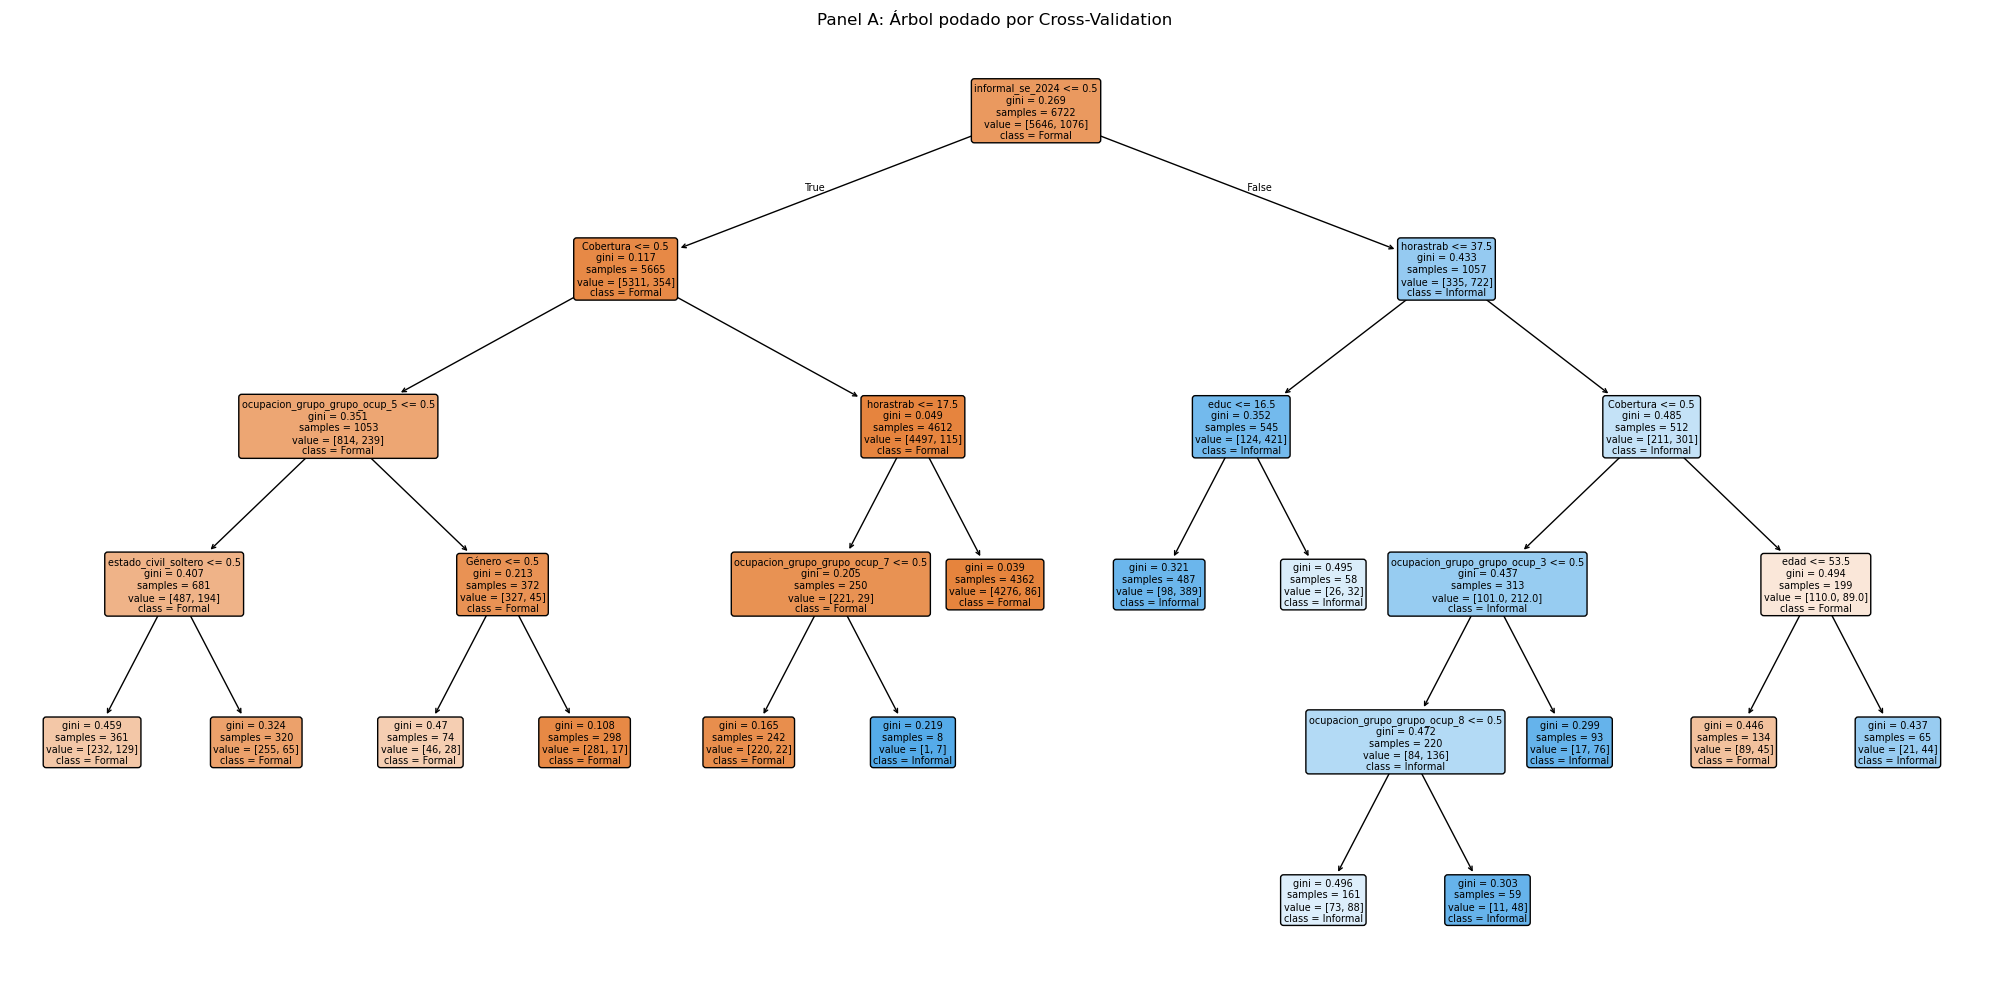

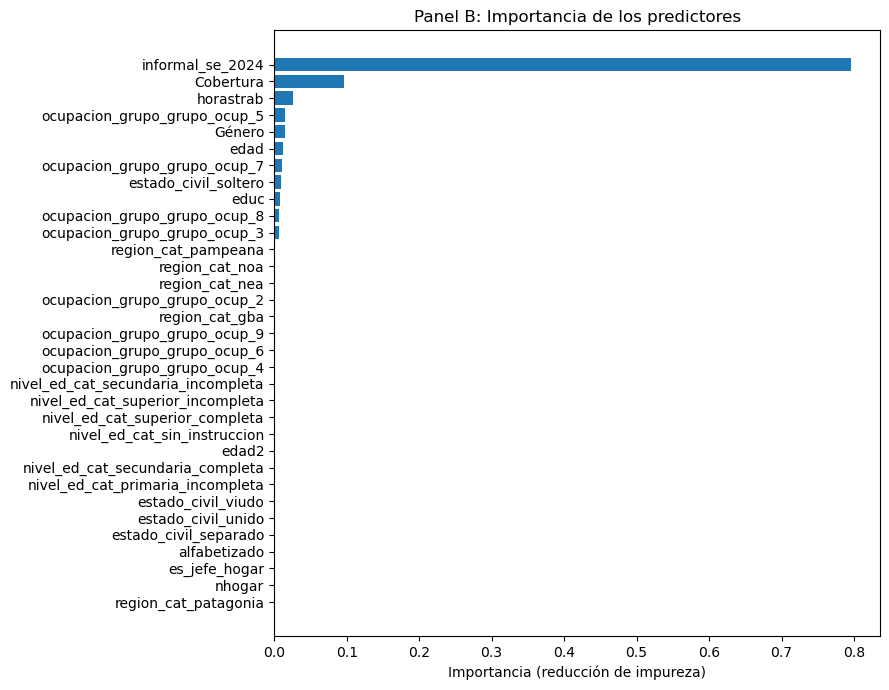

,Variable,Importancia
9,informal_se_2024,0.795997
6,Cobertura,0.096136
3,horastrab,0.025957
23,ocupacion_grupo_grupo_ocup_5,0.014997
5,Género,0.014202
0,edad,0.011816
25,ocupacion_grupo_grupo_ocup_7,0.011047
11,estado_civil_soltero,0.009361
2,educ,0.007339
26,ocupacion_grupo_grupo_ocup_8,0.007141


In [35]:
arbol_podado = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha_opt)
arbol_podado.fit(X, y)

print(f"Profundidad del árbol podado: {arbol_podado.get_depth()}")
print(f"Cantidad de hojas: {arbol_podado.get_n_leaves()}")

# Panel A: árbol
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(arbol_podado, feature_names=nombres_X, class_names=["Formal", "Informal"],
          filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title("Panel A: Árbol podado por Cross-Validation")
plt.tight_layout()
plt.show()

# Panel B: importancia de variables
importancias = pd.DataFrame({
    "Variable": nombres_X,
    "Importancia": arbol_podado.feature_importances_
}).sort_values("Importancia", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importancias["Variable"], importancias["Importancia"])
ax.invert_yaxis()
ax.set_xlabel("Importancia (reducción de impureza)")
ax.set_title("Panel B: Importancia de los predictores")
plt.tight_layout()
plt.show()

display(importancias)


Vemos que la importancia está concentrada casi por completo en **`informal_se_2024`** (79,6%), seguida de Cobertura (9,6%) y horastrab (2,6%), entre las tres explican el 88% de la reducción de impureza. El resto se reparte en fracciones menores al 1,5% entre 8 variables más (incluyendo cuatro categorías de ocupacion_grupo), y 21 de las 33 variables quedan con  importancia exactamente nula, entre ellas `edad2`, todos los `nivel_ed_cat`, casi todo `estado_civil` y las cinco categorías de `region_cat`.

Si comparamos con LASSO podemos identificar que la correspondencia es prácticamente nula. Con su λ óptimo, LASSO no anuló ninguna variable, mientras que el árbol descarta 21 de 33 de forma directa. Esto tiene sentido dado el criterio de cada método, LASSO con penalización casi nula retiene toda variable que aporte algo al ajuste dentro de la muestra, mientras que el árbol solo usa una variable si genera una partición que reduce la impureza lo suficiente como para sobrevivir la poda, adoptando un criterio mucho más exigente, que en este caso deja fuera a la gran mayoría de las categóricas nuevas (`region_cat`, la mayor parte de `nivel_ed_cat` y `estado_civil`).
Sí hay coincidencia parcial en cuáles son las más relevantes: `informal_se_2024` domina en ambos métodos, y tres de las cuatro categorías de `ocupacion_grupo`  también aparecen entre las pocas variables con importancia positiva en el árbol, apoyando la hipótesis de que esos grupos concentran señal real (o cuasi-separación) detectable por ambos métodos, a diferencia de nivel_ed_cat_sin_instruccion`, que era relevante en LASSO/Ridge pero tiene importancia nula en el árbol.

Los cuatro modelos (logit sin penalidad, LASSO, Ridge y árbol podado) están evaluados sobre la misma base con la que fueron ajustados (`datos_2025_MM`, in-sample) — es el mismo criterio que usamos para los modelos de regularización en la sección A, así que la comparación entre los cuatro es consistente. Ninguno tiene ventaja por evaluarse fuera de muestra ni desventaja por sobreajuste no controlado respecto a los demás: los cuatro comparten el mismo riesgo de estar optimistas respecto a cómo performarían en datos genuinamente nuevos.

Aclaración metodológica: la grilla de valores de `ccp_alpha` se calcula una sola vez, a partir del árbol completo ajustado sobre toda la base (`cost_complexity_pruning_path`), y luego cada valor de esa grilla se
evalúa con 5-fold CV. Es la simplificación estándar en este tipo de ejercicios; la alternativa más rigurosa recalcular la grilla de alphas dentro de cada fold, no cambia sustancialmente el resultado acá porque el árbol completo ya explora un rango de complejidad amplio, y se optó por la versión más simple.

## C. Comparación entre métodos

### C.1. Matriz de confusión, curva ROC y métricas

Se comparan los cuatro modelos: Logit sin penalidad, LASSO, Ridge y el árbol podado, evaluados sobre la misma base (2025_MM, in-sample), con un umbral de clasificación p=0,5. Se reportan las mismas métricas que en el TP3: Accuracy, Sensibilidad (Recall), Valor predictivo positivo (Precision), Especificidad y AUC-ROC.



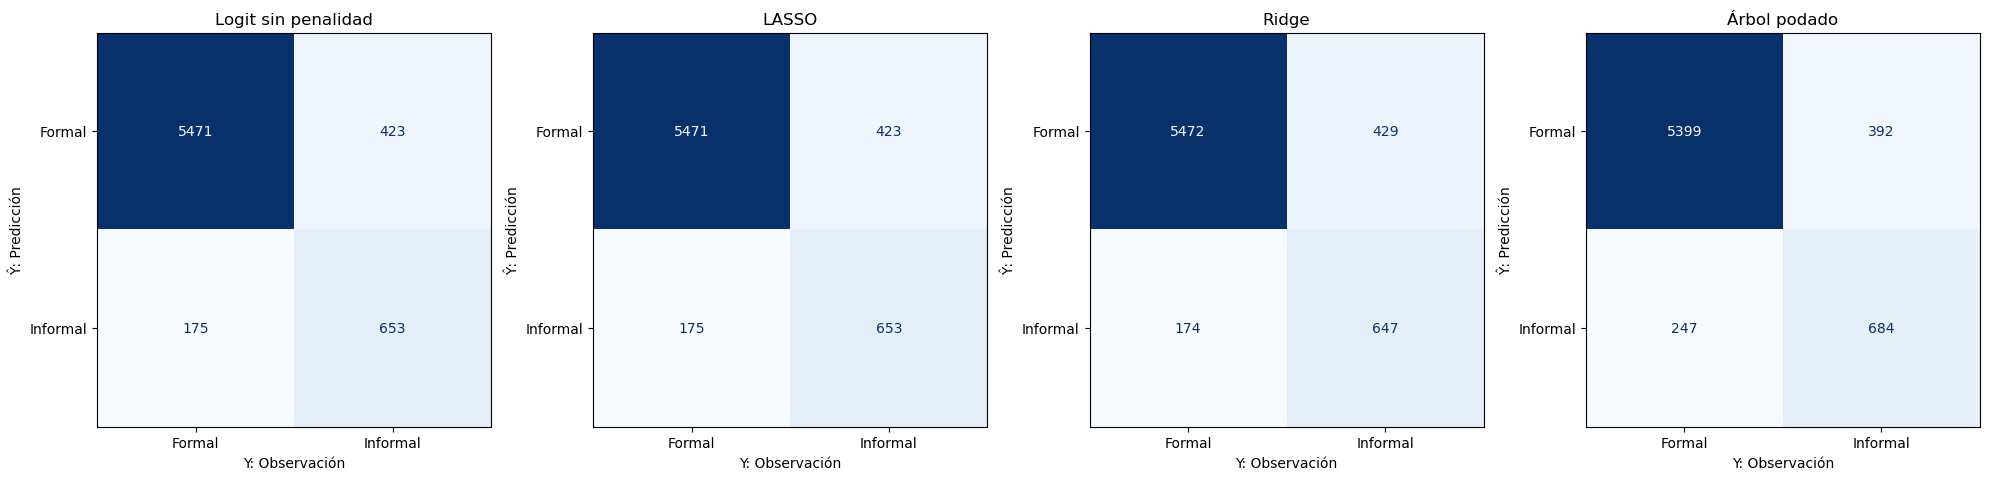

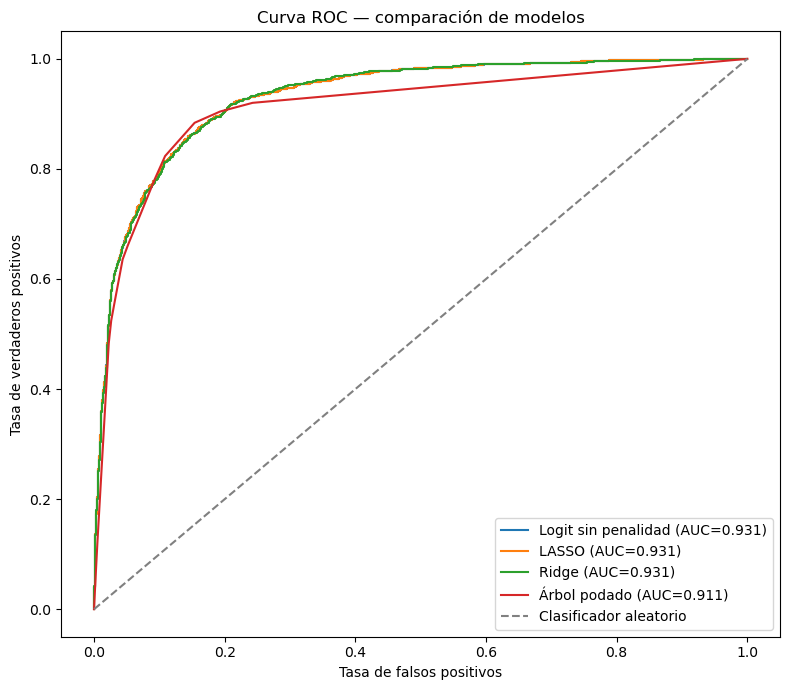

,Modelo,Accuracy,1 - Accuracy,Recall (Sensibilidad),Precision (VPP),Especificidad,AUC
0,Logit sin penalidad,0.9110,0.0890,0.6069,0.7886,0.9690,0.9311
1,LASSO,0.9110,0.0890,0.6069,0.7886,0.9690,0.9311
2,Ridge,0.9103,0.0897,0.6013,0.7881,0.9692,0.9309
3,Árbol podado,0.9049,0.0951,0.6357,0.7347,0.9563,0.9111


In [36]:
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                              accuracy_score, recall_score, precision_score, ConfusionMatrixDisplay)

X_sm = sm.add_constant(X_esc)
modelo_logit = sm.Logit(y, X_sm).fit(disp=0)
p_logit = modelo_logit.predict(X_sm)

modelo_lasso_final = LogisticRegression(penalty="l1", C=C_opt_lasso, solver="liblinear", max_iter=5000)
modelo_lasso_final.fit(X_esc, y)
p_lasso = modelo_lasso_final.predict_proba(X_esc)[:, 1]

modelo_ridge_final = LogisticRegression(penalty="l2", C=C_opt_ridge, solver="lbfgs", max_iter=5000)
modelo_ridge_final.fit(X_esc, y)
p_ridge = modelo_ridge_final.predict_proba(X_esc)[:, 1]

p_arbol = arbol_podado.predict_proba(X)[:, 1]

umbral = 0.5
modelos_comparar = {
    "Logit sin penalidad": p_logit,
    "LASSO": p_lasso,
    "Ridge": p_ridge,
    "Árbol podado": p_arbol,
}

# Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (nombre, p_hat) in zip(axes, modelos_comparar.items()):
    y_hat = (p_hat > umbral).astype(int)
    cm = confusion_matrix(y, y_hat)
    disp = ConfusionMatrixDisplay(cm.T, display_labels=["Formal", "Informal"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)
    ax.set_xlabel("Y: Observación")
    ax.set_ylabel("Ŷ: Predicción")
plt.tight_layout()
plt.show()

# Curva ROC
fig, ax = plt.subplots(figsize=(8, 7))
for nombre, p_hat in modelos_comparar.items():
    fpr, tpr, _ = roc_curve(y, p_hat)
    auc = roc_auc_score(y, p_hat)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Clasificador aleatorio")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC — comparación de modelos")
ax.legend()
plt.tight_layout()
plt.show()

# Tabla de métricas (p=0,5): Accuracy, Recall, Precision, Especificidad, AUC
filas = []
for nombre, p_hat in modelos_comparar.items():
    y_hat = (p_hat > umbral).astype(int)
    cm_i = confusion_matrix(y, y_hat)
    tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
    filas.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y, y_hat),
        "1 - Accuracy": 1 - accuracy_score(y, y_hat),
        "Recall (Sensibilidad)": recall_score(y, y_hat),
        "Precision (VPP)": precision_score(y, y_hat),
        "Especificidad": tn_i / (tn_i + fp_i),
        "AUC": roc_auc_score(y, p_hat),
    })
tabla_metricas = pd.DataFrame(filas).round(4)
display(tabla_metricas)


Los cuatro modelos tienen desempeño similar y alto (AUC 0,911-0,931). Logit, LASSO y Ridge quedan prácticamente empatados entre sí (Accuracy 91,0%-91,1%, AUC 0,931 los tres), coherente con que LASSO no anuló ninguna variable, y el árbol podado queda un escalón por 
debajo en ambas métricas (Accuracy 90,5%, AUC 0,911).

Sin embargo, el ranking se invierte al mirar Recall y Precision por separado, el árbol tiene el mayor Recall de los cuatro, a costa de la menor Precision. Es decir, el árbol sigue detectando oporcionalmente más informales reales, pero a costa de más falsos positivos, el mismo patrón que en la versión con tam_empresa. 


### C.2. Trade-off entre comunicación y performance predictiva

¿Trade-off entre comunicación y performance? ¿Ventaja de un método no lineal?
El árbol sigue siendo más fácil de comunicar, pero esa ventaja se paga en performance: Accuracy 90,5% vs. 91,0%-91,1% (logit/LASSO), y AUC 0,911 vs. 0,931, una brecha de 2 puntos en AUC, mayor que en Accuracy. 
La pérdida no es pareja, el árbol compensa parte de esa brecha con mejor Recall (63,6% vs. 60,1%-60,7%), pero paga más en Precision (73,5% vs. 78,8%-78,9%). 

Incorporando (1-accuracy): la diferencia es de 0,61 p.p. entre el árbol (9,51%) y el logit/ LASSO (8,90%) — chica en términos absolutos. Descomponiendo el tipo de error: en el logit/LASSO,  el 70,7% del error son falsos negativos (423 de 598) y el 29,3% falsos positivos; en el árbol, 
61,3% son falsos negativos (392 de 639) y 38,7% falsos positivos. Es decir, los tres modelos  fallan mayoritariamente por falsos negativos (menor Recall que Precision), pero el árbol 
desplaza relativamente más error hacia falsos positivos que los modelos lineales.

**Recordando que la Secretaría de Trabajo está interesada en identificar grupos vulnerables para dirigir recursos de un programa de trabajo, ¿cambió la respuesta con respecto a cuál es el "mejor" modelo para asignar recursos escasos a los más necesitados?**

Sí cambió, `informal_se_2024` es el predictor dominante en los cuatro modelos. La variable más útil para focalizar recursos no es una característica estructural del puesto, sino el historial de informalidad de la persona, lo que sugiere que el programa se beneficiaría de datos longitudinales (ya sea cruces con AFIP o ANSES) y no solo de un relevamiento transversal como la EPH.

Para la elección de modelo, la decisión sigue siendo de política, no estadística, pero con esta base la brecha entre opciones es más chica que antes: si prioriza cobertura (minimizar falsos  negativos), conviene el **árbol** (Recall 63,6% vs. 60,1%-60,7%); si prioriza eficiencia del 
gasto (minimizar falsos positivos), conviene el **logit o LASSO** (Precision 78,8%-78,9% vs.  73,5% del árbol). A diferencia de la versión con `tam_empresa`, acá el árbol no compensa su menor precision con una ganancia grande de Recall (solo ~3 p.p.), así que la ventaja de usarlo para maximizar cobertura es más marginal que antes — la Secretaría debe sopesar si esa ganancia chica  en cobertura justifica perder 5 p.p. de Precision y 2 puntos de AUC.

## Uso de la IA

En este trabajo la IA nos ayudó a agilizar el armado del código y con la interpretación de los gráficos a profundidad que no nos había ocurrido en el trabajo anterior. Fue muy útil para ordenar paso a paso el código, especialmente con la segunda parte ya que nos encontramos con muchos errores que no permitían correr el código correctamente.
Prompts y LLMs utilizados:
